<H2>MERGING THE DATASETS</H2>
For our project, we will be merging two datasets, where:</br>
<li> Dataset1 contains census information such as literacy rate, urban population, rural population, unemployment, dominant religions, and 
</li>
<li> Dataset2 contains statistics of various crimes against women over the time span 2001-2020</li> </br>

In [1]:
import pandas as pd
import re
df = pd.read_csv('Final-censusdataset-India.csv')  
print(df.head(3))

     state                                           District  persons  \
0  ANdaman  District Nicobars (01), Andaman & Nicobar Isla...   314084   
1  ANdaman  District Nicobars (02), Andaman & Nicobar Isla...    42068   
2   Andhra        District Adilabad (01), Andhra Pradesh (28)  2488003   

      Male   Female    rural  Person lit_rate  Male lit_Rate  Female lit_Rate  \
0   170319   143765   197886            82.49          87.36            76.62   
1    22653    19415    42068            72.35          78.55            65.01   
2  1250958  1237045  1827986            52.68          64.98            40.30   

   Tempworkers  ...  religion1 population     Religion2  Religion2 Population  \
0       166631  ...                235862  2.Christians                 49033   
1        19623  ...                 28145      2.Hindus                 10727   
2      1423248  ...               2207843           NaN                236844   

   Religion3  religion3 Population inhabitadevillages

In [2]:
def clean_district_name(district_name):
    cleaned_name = district_name.replace("District ", "")
    cleaned_name = re.sub(r"\(\d+\), .* \(\d+\)", "", cleaned_name).strip()  
    return cleaned_name

df['District'] = df['District'].apply(clean_district_name)
df.to_csv('cleaned_district_name.csv', index=False)


In [3]:
df1 = pd.read_csv('cleaned_district_name.csv')  
print(df.head(3))

     state  District  persons     Male   Female    rural  Person lit_rate  \
0  ANdaman  Nicobars   314084   170319   143765   197886            82.49   
1  ANdaman  Nicobars    42068    22653    19415    42068            72.35   
2   Andhra  Adilabad  2488003  1250958  1237045  1827986            52.68   

   Male lit_Rate  Female lit_Rate  Tempworkers  ...  religion1 population  \
0          87.36            76.62       166631  ...                235862   
1          78.55            65.01        19623  ...                 28145   
2          64.98            40.30      1423248  ...               2207843   

      Religion2  Religion2 Population  Religion3  religion3 Population  \
0  2.Christians                 49033  3.Muslims                 27134   
1      2.Hindus                 10727  3.Muslims                  2131   
2           NaN                236844        NaN                 24392   

  inhabitadevillages  drinkingwater electricity  primary school  \
0              331

In [4]:
df2 = pd.read_csv('women-crimedataset-India (2).csv')  
print(df.head(3))

     state  District  persons     Male   Female    rural  Person lit_rate  \
0  ANdaman  Nicobars   314084   170319   143765   197886            82.49   
1  ANdaman  Nicobars    42068    22653    19415    42068            72.35   
2   Andhra  Adilabad  2488003  1250958  1237045  1827986            52.68   

   Male lit_Rate  Female lit_Rate  Tempworkers  ...  religion1 population  \
0          87.36            76.62       166631  ...                235862   
1          78.55            65.01        19623  ...                 28145   
2          64.98            40.30      1423248  ...               2207843   

      Religion2  Religion2 Population  Religion3  religion3 Population  \
0  2.Christians                 49033  3.Muslims                 27134   
1      2.Hindus                 10727  3.Muslims                  2131   
2           NaN                236844        NaN                 24392   

  inhabitadevillages  drinkingwater electricity  primary school  \
0              331

In [5]:
df1['District'] = df1['District'].str.strip().str.lower()
df2['District'] = df2['District'].str.strip().str.lower()


In [6]:
state_replacements = {
    'andhra': 'ANDHRA PRADESH',
    'anaman': 'A & N ISLANDS',
    'd & n haweli': 'D & N HAVELI',
    'delhi': 'DELHI UT',
    'hp': 'HIMACHAL PRADESH',
    'jk': 'JAMMU & KASHMIR',
    'tn': 'TAMIL NADU',
    'up': 'UTTAR PRADESH'
}

df1['state'] = df1['state'].replace(state_replacements)
df2['state'] = df2['state'].replace(state_replacements)

In [7]:
merged_df = pd.merge(df2, df1, left_on='District', right_on='District', how='inner')


In [8]:
merged_df.head()

,state_x,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion1 population,Religion2,Religion2 Population,Religion3,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility
0,ANDHRA PRADESH,adilabad,2001.0,101,60,50,0,50,46,30,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
1,ANDHRA PRADESH,adilabad,2002.0,100,79,37,0,37,42,32,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
2,ANDHRA PRADESH,adilabad,2003.0,107,65,35,0,35,46,16,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
3,ANDHRA PRADESH,adilabad,2004.0,113,83,50,0,50,48,42,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
4,ANDHRA PRADESH,adilabad,2005.0,108,48,53,0,53,65,46,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976


In [9]:
merged_df.to_csv('merged_dataset.csv', index=False)


<H2>DATA PREPROCESSING:</H2>

Since we have two columns containing State name values, we will drop one of the columns

In [10]:
merged_df.rename(columns={'state_x': 'state'}, inplace=True)
merged_df.drop(columns=['state_y'], inplace=True)

print(merged_df.head(3))
merged_df.to_csv('merged_dataset.csv', index=False)


            state  District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0  ANDHRA PRADESH  adilabad  2001.0    101                60   50   
1  ANDHRA PRADESH  adilabad  2002.0    100                79   37   
2  ANDHRA PRADESH  adilabad  2003.0    107                65   35   

  CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0              0         50                     46   
1              0         37                     42   
2              0         35                     46   

  KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ... religion1 population  \
0                                          30  ...              2207843   
1                                          32  ...              2207843   
2                                          16  ...              2207843   

  Religion2 Religion2 Population Religion3 religion3 Population  \
0       NaN               236844       NaN                24392   
1       NaN               236844       NaN                24392   
2   

<H3> REARRANGING THE MERGED DATASET IN ASCENDING ORDER (IN ORDER OF 'state', 'District', 'YEAR' columns) and RESETTING THE INDEX</H3>


In [11]:
merged_df = merged_df.sort_values(by=['state', 'District', 'YEAR'])
merged_df = merged_df.reset_index(drop=True)
merged_df.head()

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion1 population,Religion2,Religion2 Population,Religion3,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility
0,A & N ISLANDS,north,2012.0,5,0,4,0,4,0,0,...,609493,2.Muslims,126093,3.Sikhs,20819,5.0,5.0,4.0,3.0,3
1,A & N ISLANDS,north,2012.0,5,0,4,0,4,0,0,...,22603,2.Hindus,16128,3.Christians,1623,53.0,53.0,46.0,42.0,44
2,A & N ISLANDS,south,2012.0,8,3,8,0,8,7,6,...,1824645,2.Muslims,314015,3.Sikhs,75102,16.0,16.0,16.0,12.0,7
3,A & N ISLANDS,south,2012.0,8,3,8,0,8,7,6,...,84213,2.Buddhists,31109,3.Christians,12757,145.0,145.0,142.0,131.0,99
4,ANDHRA PRADESH,adilabad,2001.0,101,60,50,0,50,46,30,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976


<H3> STANDARDIZING ALL THE STATE NAMES</H3>


In [12]:
def standardize_state_name(state_name):
    state_mapping = {
        'CHHATISGARH': 'CHHATTISGARH',
        'CHHATTISGARH': 'CHHATTISGARH',
        'TAMILNADU': 'TAMIL NADU',
        'TAMIL NADU': 'TAMIL NADU',
        'DELHI': 'DELHI UT',
        'DELHI UT': 'DELHI UT',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYAPRADESH': 'MADHYA PRADESH',
        'Lakshadweep': 'LAKSHADWEEP',
        'LAKSHADWEEP': 'LAKSHADWEEP',
        'ANDHRA PRADESH ': 'ANDHRA PRADESH',
        'ANDHRA PRADESH': 'ANDHRA PRADESH',
        
    }
    return state_mapping.get(state_name, state_name)

merged_df['state'] = merged_df['state'].apply(standardize_state_name)

merged_df['state'].unique()

array(['A & N ISLANDS', 'ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM',
       'BIHAR', 'CHANDIGARH', 'CHATTISGARH', 'CHHATTISGARH', 'Chandigarh',
       'DAMAN', 'DAMAN & DIU', 'DELHI UT', 'DIU', 'GOA', 'GUJARAT',
       'HARYANA', 'HIMACHAL PRADESH', 'JAMMU & KASHMIR', 'JHARKHAND',
       'KARNATAKA', 'KERALA', 'LAKSHADWEEP', 'MADHYA PRADESH',
       'MADHYA PRADESH  ', 'MAHARASHTRA', 'MANIPUR', 'MEGHALAYA',
       'MIZORAM', 'NAGALAND', 'ODISHA', 'PUDUCHERRY', 'PUNJAB',
       'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA',
       'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL'], dtype=object)

In [13]:
merged_df['Religion1'] = merged_df['Religion1'].str.split('.').str[1].str.strip()
merged_df['Religion2'] = merged_df['Religion2'].str.split('.').str[1].str.strip()
merged_df['Religion3'] = merged_df['Religion3'].str.split('.').str[1].str.strip()

print(merged_df)
merged_df.to_csv('merged_dataset.csv', index=False)


               state        District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0      A & N ISLANDS           north  2012.0      5                 0    4   
1      A & N ISLANDS           north  2012.0      5                 0    4   
2      A & N ISLANDS           south  2012.0      8                 3    8   
3      A & N ISLANDS           south  2012.0      8                 3    8   
4     ANDHRA PRADESH        adilabad  2001.0    101                60   50   
...              ...             ...     ...    ...               ...  ...   
6673     WEST BENGAL  uttar dinajpur  2010.0     63               106  130   
6674     WEST BENGAL  uttar dinajpur  2011.0     66               178  126   
6675     WEST BENGAL  uttar dinajpur  2012.0    110               283   92   
6676     WEST BENGAL  uttar dinajpur  2015.0    NaN                86   50   
6677     WEST BENGAL  uttar dinajpur  2019.0      0                39   42   

     CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0     

In [14]:
print(merged_df.columns)


Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'persons', 'Male',
       'Female', 'rural', 'Person lit_rate', 'Male lit_Rate',
       'Female lit_Rate', 'Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'Religion1', 'religion1 population', 'Religion2',
       'Religion2 Population', 'Religion3', 'religion3 Population',
       'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school',
       'Medical facility'],
      dtype='object')


For the purpose of this study, while analysing crime patterns against women in India, we will look at the recent census parameters: such as literacy rate (overall, male literacy, female literacy
'Total Population'
'Male Population',
'Female Population', 
'rural', 
'urban', 
'Personlit_rate',
'Mlit_Rate', 
'Flit_Rate', 
'Totalworkers',
'Mainworkers', 
'Marginal workers', 
'Nonworkers', 
'Religion1',
'religion1 population', 'Religion2', 'Religion2 Population',



and other irrelevant columns for the purpose of this study ie 'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility', we will drop from the dataset
       

<H2> DERIVED COLUMNS:</H2>

In [15]:
# Calculating unemployment rate
merged_df['unemployment_rate'] = (merged_df['Nonworkers'] / (merged_df['Tempworkers'] + merged_df['Mainworkers'] + merged_df['Marginal workers'])) * 100

# Calculating urban population
merged_df['persons'] = pd.to_numeric(merged_df['persons'], errors='coerce')
merged_df['rural'] = pd.to_numeric(merged_df['rural'], errors='coerce')
merged_df['urban_population'] = merged_df['persons'] - merged_df['rural']



In [16]:
columns_to_convert = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
    'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

for column in columns_to_convert:
    merged_df[column] = pd.to_numeric(merged_df[column], errors='coerce')

In [17]:
#Calculating total number of cognizable offences
"""As per CRPC Schedule I, the following are considered Cognizable offences
'MURDER', 'ATTEMPT TO MURDER', 'RAPE', ' CUSTODIAL RAPE', 'OTHER RAPE','KIDNAPPING & ABDUCTION', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS','KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

cognizable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Cognizable Offences'] = merged_df[cognizable_offences].sum(axis=1)



In [18]:
#Calculating total number of Non-Bailable offences
"""As per CRPC Schedule I, the following are considered Non-Bailable offences
'MURDER', 'ATTEMPT TO MURDER', RAPE',' CUSTODIAL RAPE', 'OTHER RAPE', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS', 
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 
'CRUELTY BY HUSBAND OR HIS RELATIVES','IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

non_bailable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS',
    'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Non-Bailable Offences'] = merged_df[non_bailable_offences].sum(axis=1)

merged_df.head(3)

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility,unemployment_rate,urban_population,Total Cognizable Offences,Total Non-Bailable Offences
0,A & N ISLANDS,north,2012.0,5.0,0,4,0.0,4.0,0,0,...,20819,5.0,5.0,4.0,3.0,3,102.287058,734940.0,18.0,17.0
1,A & N ISLANDS,north,2012.0,5.0,0,4,0.0,4.0,0,0,...,1623,53.0,53.0,46.0,42.0,44,37.142129,1248.0,18.0,17.0
2,A & N ISLANDS,south,2012.0,8.0,3,8,0.0,8.0,7,6,...,75102,16.0,16.0,16.0,12.0,7,95.591144,2106262.0,63.0,53.0


<H2> RENAMING CERTAIN COLUMNS:</H2>

In [19]:
merged_df.rename(columns={'rural': 'rural_population'}, inplace=True)

merged_df.rename(columns={'Religion1': 'First Dominant Religion'}, inplace=True)

merged_df.rename(columns={'Religion2': 'Second Dominant Religion'}, inplace=True)

merged_df.rename(columns={'persons': 'Total Population'}, inplace=True)

merged_df.rename(columns={'Male': 'Male Population'}, inplace=True)

merged_df.rename(columns={'Female': 'Female Population'}, inplace=True)

merged_df.rename(columns={'Person lit_rate': 'Total Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Male lit_Rate': 'Male Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Female lit_Rate': 'Female Literacy Rate'}, inplace=True)



<H2> REMOVING ANY DUPLICATE ROWS</H2>
<H4> removing duplicates where the state, District, and YEAR values are the same</H4>

In [20]:
merged_df = merged_df.drop_duplicates(subset=['state', 'District', 'YEAR'], keep='last')

merged_df

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility,unemployment_rate,urban_population,Total Cognizable Offences,Total Non-Bailable Offences
1,A & N ISLANDS,north,2012.0,5.0,0,4,0.0,4.0,0,0,...,1623,53.0,53.0,46.0,42.0,44,37.142129,1248.0,18.0,17.0
3,A & N ISLANDS,south,2012.0,8.0,3,8,0.0,8.0,7,6,...,12757,145.0,145.0,142.0,131.0,99,44.360266,3946.0,63.0,53.0
4,ANDHRA PRADESH,adilabad,2001.0,101.0,60,50,0.0,50.0,46,30,...,24392,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,727.0,647.0
5,ANDHRA PRADESH,adilabad,2002.0,100.0,79,37,0.0,37.0,42,32,...,24392,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,834.0,729.0
6,ANDHRA PRADESH,adilabad,2003.0,107.0,65,35,0.0,35.0,46,16,...,24392,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,763.0,678.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6673,WEST BENGAL,uttar dinajpur,2010.0,63.0,106,130,0.0,130.0,118,99,...,13172,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1259.0,1140.0
6674,WEST BENGAL,uttar dinajpur,2011.0,66.0,178,126,0.0,126.0,172,149,...,13172,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1418.0,1245.0
6675,WEST BENGAL,uttar dinajpur,2012.0,110.0,283,92,0.0,92.0,306,258,...,13172,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1976.0,1665.0
6676,WEST BENGAL,uttar dinajpur,2015.0,NaN,86,50,0.0,NaN,1,72,...,13172,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,844.0,838.0


<H2> DROPPING IRRELEVANT COLUMNS:</H2>

In [21]:
# Dropping irrelevant columns
irrelevant_columns = ['inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility']
merged_df = merged_df.drop(columns=irrelevant_columns)

#Dropping columns that we don't need anymore
irrelevant_columns = ['Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'religion1 population', 
       'Religion2 Population', 'Religion3', 'religion3 Population']
merged_df = merged_df.drop(columns=irrelevant_columns)

print(merged_df.head(3))

            state  District    YEAR  MURDER  ATTEMPT TO MURDER  RAPE  \
1   A & N ISLANDS     north  2012.0     5.0                  0     4   
3   A & N ISLANDS     south  2012.0     8.0                  3     8   
4  ANDHRA PRADESH  adilabad  2001.0   101.0                 60    50   

   CUSTODIAL RAPE  OTHER RAPE  KIDNAPPING & ABDUCTION  \
1             0.0         4.0                       0   
3             0.0         8.0                       7   
4             0.0        50.0                      46   

   KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ...  rural_population  \
1                                            0  ...           39782.0   
3                                            6  ...          127579.0   
4                                           30  ...         1827986.0   

   Total Literacy Rate  Male Literacy Rate  Female Literacy Rate  \
1                67.21               75.69                 55.39   
3                67.31               74.29           

In [22]:

merged_df.to_csv('final_dataset.csv', index=False)


<H2>VISUALISING CRIME TRENDS</H2>
<H4> PLEASE SELECT A STATE, DISTRICT AND TYPE OF CRIME FROM THE DROPDOWN MENU </H4>

Dropdown(description='State:', index=6, options=('ANDHRA PRADESH', 'BIHAR', 'CHANDIGARH', 'DAMAN & DIU', 'GOA'…

Dropdown(description='District:', index=6, options=('bilaspur', 'chamba', 'hamirpur', 'kangra', 'kinnaur', 'ku…

Dropdown(description='Crime Type:', index=10, options=('MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE'…

Button(description='Submit', style=ButtonStyle())

/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/rudranighosh/anaconda/anaco

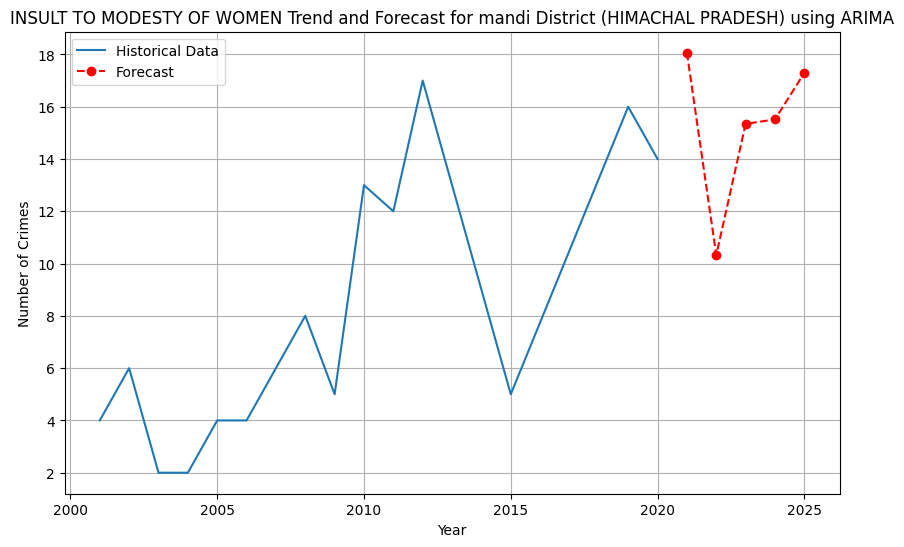

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

df = pd.read_csv('final_dataset.csv')

crime_columns = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
    'Total Cognizable Offences', 'Total Non-Bailable Offences'
]
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=crime_columns)


def plot_crime_trend(btn):
    # Clear previous outputs
    clear_output(wait=True)
    
    # Display widgets again
    display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)
    
    state = state_dropdown.value
    district = district_dropdown.value
    crime_type = crime_type_dropdown.value
    
    state_df = df[df['state'] == state]
    filtered_df = state_df[state_df['District'] == district]
    filtered_df = filtered_df.set_index('YEAR')
    filtered_df = filtered_df[[crime_type]]
    
    plt.figure(figsize=(10, 6))
    filtered_df.plot(marker='o', linestyle='-')
    plt.title(f'{crime_type} Trend for {district} District ({state})')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    plt.show()

# Function to update the district dropdown based on selected state
def update_district_dropdown(*args):
    state = state_dropdown.value
    districts = df[df['state'] == state]['District'].value_counts()
    valid_districts = districts[districts >= 5].index.tolist()
    district_dropdown.options = valid_districts

state_district_counts = df.groupby(['state', 'District']).size().reset_index(name='Counts')

# Filter out states where all districts have at least 5 records
valid_states = state_district_counts[state_district_counts['Counts'] >= 5].groupby('state').filter(lambda x: len(x) == len(state_district_counts[state_district_counts['state'] == x.name]))

# Get unique list of states meeting the criteria
valid_state_list = valid_states['state'].unique()


# Setup dropdowns and button
state_dropdown = widgets.Dropdown(options=valid_state_list, description='State:')
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=crime_columns)
district_dropdown = widgets.Dropdown(description='District:')
submit_button = widgets.Button(description="Submit")

# Ensure the district dropdown updates when the state selection changes
state_dropdown.observe(update_district_dropdown, names='value')

# Button click event
submit_button.on_click(plot_crime_trend)

# Display widgets
display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)


Dropdown(description='State:', index=6, options=('ANDHRA PRADESH', 'BIHAR', 'CHANDIGARH', 'DAMAN & DIU', 'GOA'…

Dropdown(description='District:', index=6, options=('bilaspur', 'chamba', 'hamirpur', 'kangra', 'kinnaur', 'ku…

Dropdown(description='Crime Type:', options=('MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER R…

Button(description='Submit', style=ButtonStyle())

/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/rudranighosh/anaconda/anaconda3/lib/pytho

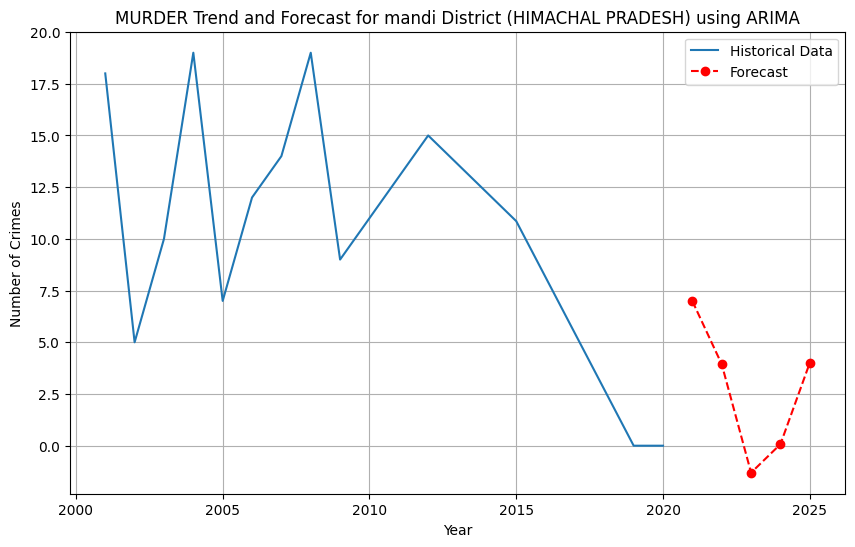

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# Read the dataset
df = pd.read_csv('final_dataset.csv')

def plot_crime_trend(btn):
    clear_output(wait=True)
    display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)
    
    state = state_dropdown.value
    district = district_dropdown.value
    crime_type = crime_type_dropdown.value
    
    state_df = df[df['state'] == state]
    filtered_df = state_df[state_df['District'] == district]
    filtered_df = filtered_df.set_index('YEAR')
    filtered_df = filtered_df[[crime_type]]
    
    plt.figure(figsize=(10, 6))
    filtered_df.plot(marker='o', linestyle='-')
    plt.title(f'{crime_type} Trend for {district} District ({state})')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    plt.show()

# Function to update district dropdown based on selected state
def update_district_dropdown(*args):
    state = state_dropdown.value
    districts = df[df['state'] == state]['District'].value_counts()
    valid_districts = districts[districts >= 5].index.tolist()
    district_dropdown.options = valid_districts

# Create dropdowns and button
state_dropdown = widgets.Dropdown(options=df['state'].unique(), description='State:')
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=df.columns[3:])
district_dropdown = widgets.Dropdown(description='District:')
submit_button = widgets.Button(description="Submit")

# Ensure district dropdown updates when state selection changes
state_dropdown.observe(update_district_dropdown, names='value')

# Initialize district dropdown with valid districts based on initial state dropdown value
update_district_dropdown()

# Handle button click event
submit_button.on_click(plot_crime_trend)

# Display widgets
display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

df = pd.read_csv('final_dataset.csv')

def plot_crime_trend(btn):
    clear_output(wait=True)
    display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)
    
    state = state_dropdown.value
    district = district_dropdown.value
    crime_type = crime_type_dropdown.value
    
    state_df = df[df['state'] == state]
    filtered_df = state_df[state_df['District'] == district]
    filtered_df = filtered_df.set_index('YEAR')
    filtered_df = filtered_df[[crime_type]]
    
    plt.figure(figsize=(10, 6))
    filtered_df.plot(marker='o', linestyle='-')
    plt.title(f'{crime_type} Trend for {district} District ({state})')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.grid(True)
    plt.show()

# Function to update district dropdown based on selected state
def update_district_dropdown(*args):
    state = state_dropdown.value
    districts = df[df['state'] == state]['District'].value_counts()
    valid_districts = districts[districts >= 5].index.tolist()
    district_dropdown.options = valid_districts

# Function to update state dropdown based on available districts
def update_state_dropdown(*args):
    states_with_valid_districts = df.groupby('state').filter(lambda x: (x['District'].nunique() >= 1) and (x['District'].nunique() >= 5))
    valid_states = states_with_valid_districts['state'].unique()
    state_dropdown.options = valid_states

# Create dropdowns and button
state_dropdown = widgets.Dropdown(description='State:')
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=df.columns[3:])
district_dropdown = widgets.Dropdown(description='District:')
submit_button = widgets.Button(description="Submit")

# Ensure district dropdown updates when state selection changes
state_dropdown.observe(update_district_dropdown, names='value')

# Ensure state dropdown updates based on available districts
district_dropdown.observe(update_state_dropdown, names='value')

# Handle button click event
submit_button.on_click(plot_crime_trend)

# Initialize district dropdown with valid districts based on initial state dropdown value
update_district_dropdown()

# Initialize state dropdown with valid states
update_state_dropdown()

# Display widgets
display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)


Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR', 'CHATTISGARH'…

Dropdown(description='District:', options=(), value=None)

Dropdown(description='Crime Type:', options=('MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER R…

Button(description='Submit', style=ButtonStyle())

<H2>FORECASTING CRIME TRENDS (USING LINEAR REGRESSION) FOR NEXT 5 YEARS</H2>
<H4> PLEASE SELECT A STATE, DISTRICT AND TYPE OF CRIME FROM THE DROPDOWN MENU </H4>

Dropdown(description='State:', index=6, options=('ANDHRA PRADESH', 'BIHAR', 'CHANDIGARH', 'DAMAN & DIU', 'GOA'…

Dropdown(description='District:', index=5, options=('bilaspur', 'chamba', 'hamirpur', 'kangra', 'kinnaur', 'ku…

Dropdown(description='Crime Type:', options=('MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER R…

Button(description='Submit', style=ButtonStyle())

/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/rudranighosh/anaconda/anaconda3/lib/pytho

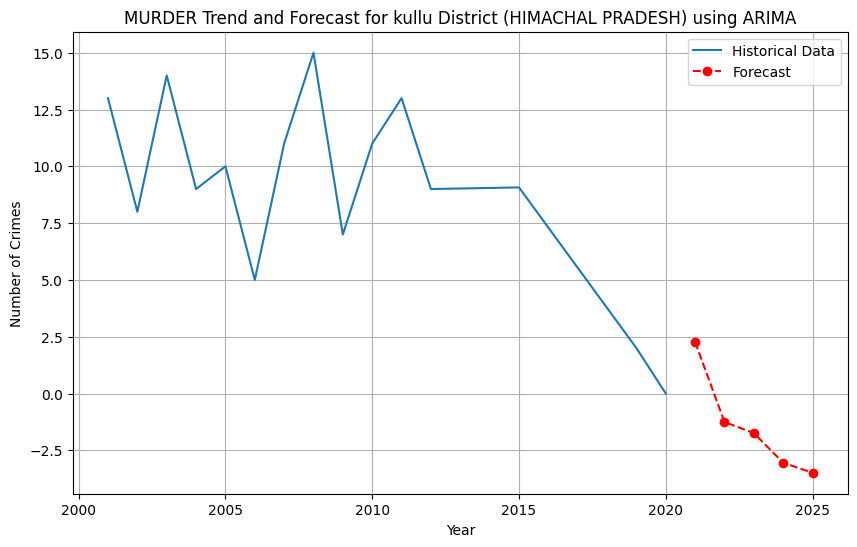

In [26]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from sklearn.linear_model import LinearRegression

df = pd.read_csv('final_dataset.csv')

def plot_crime_trend(btn):
    clear_output(wait=True)
    
    display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)
    
    state = state_dropdown.value
    district = district_dropdown.value
    crime_type = crime_type_dropdown.value
    
    state_df = df[df['state'] == state]
    filtered_df = state_df[state_df['District'] == district]
    filtered_df = filtered_df.sort_values('YEAR')
    
    # Preparing data for linear regression
    X = filtered_df['YEAR'].values.reshape(-1, 1)  # Feature matrix
    y = filtered_df[crime_type].fillna(filtered_df[crime_type].mean()).values  # Target variable with NaN replaced by mean
    
    # Fitting linear regression model
    model = LinearRegression()
    model.fit(X, y)
    
    # Create a range of future years for predictions
    future_years = np.arange(filtered_df['YEAR'].max() + 1, filtered_df['YEAR'].max() + 6).reshape(-1, 1)
    
    # Prediction of future crimes
    future_crimes = model.predict(future_years)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', label='Historical Data')
    plt.plot(X, model.predict(X), color='green', linestyle='-', linewidth=2, label='Trend Line')
    plt.plot(future_years, future_crimes, color='red', linestyle='--', marker='o', label='Forecast')
    
    plt.title(f'{crime_type} Trend and Forecast for {district} District ({state})')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.legend()
    plt.grid(True)
    plt.show()

# update the district dropdown based on selected state
def update_district_dropdown(*args):
    state = state_dropdown.value
    districts = df[df['state'] == state]['District'].value_counts()
    valid_districts = districts[districts >= 5].index.tolist()
    district_dropdown.options = valid_districts

# Creating dropdowns and button
state_dropdown = widgets.Dropdown(options=valid_state_list, description='State:')
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=crime_columns)
district_dropdown = widgets.Dropdown(description='District:')
submit_button = widgets.Button(description="Submit")

# Ensuring district dropdown updates when the state selection changes
state_dropdown.observe(update_district_dropdown, names='value')

submit_button.on_click(plot_crime_trend)

display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)


<H2>FORECASTING CRIME TRENDS (USING ARIMA MODEL) FOR NEXT 5 YEARS</H2>
<H4> PLEASE SELECT A STATE, DISTRICT AND TYPE OF CRIME FROM THE DROPDOWN MENU </H4>

Dropdown(description='State:', index=6, options=('ANDHRA PRADESH', 'BIHAR', 'CHANDIGARH', 'DAMAN & DIU', 'GOA'…

Dropdown(description='District:', index=3, options=('bilaspur', 'chamba', 'hamirpur', 'kangra', 'kinnaur', 'ku…

Dropdown(description='Crime Type:', options=('MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER R…

Button(description='Submit', style=ButtonStyle())

/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/rudranighosh/anaconda/anaconda3/lib/pytho

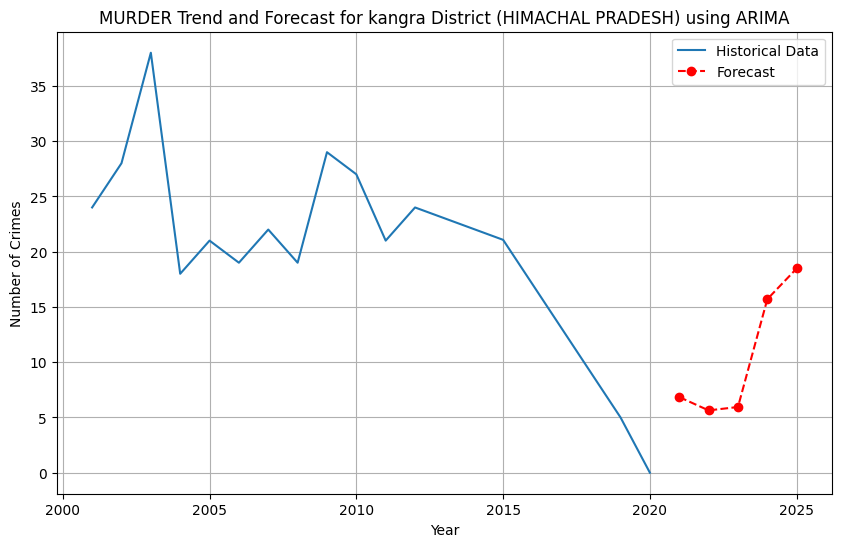

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('final_dataset.csv')

def plot_crime_trend(btn):
    clear_output(wait=True)
    
    display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)
    
    state = state_dropdown.value
    district = district_dropdown.value
    crime_type = crime_type_dropdown.value
    
    state_df = df[df['state'] == state]
    filtered_df = state_df[state_df['District'] == district]
    filtered_df = filtered_df.sort_values('YEAR')
    
    # Preparing data for ARIMA
    y = filtered_df[crime_type].fillna(filtered_df[crime_type].mean())  # Target variable with NaN replaced by mean
    
    # Fitting ARIMA model
    model = ARIMA(y, order=(5,1,0))  # ARIMA(p,d,q) with p=5, d=1, q=0
    model_fit = model.fit()
    
    # Forecast next 5 years
    forecast = model_fit.forecast(steps=5)
    future_years = np.arange(filtered_df['YEAR'].max() + 1, filtered_df['YEAR'].max() + 6)
    
    
    plt.figure(figsize=(10, 6))
    plt.plot(filtered_df['YEAR'], y, label='Historical Data')
    plt.plot(future_years, forecast, color='red', linestyle='--', marker='o', label='Forecast')
    
    plt.title(f'{crime_type} Trend and Forecast for {district} District ({state}) using ARIMA')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.legend()
    plt.grid(True)
    plt.show()

def update_district_dropdown(*args):
    state = state_dropdown.value
    districts = df[df['state'] == state]['District'].value_counts()
    valid_districts = districts[districts >= 5].index.tolist()
    district_dropdown.options = valid_districts

state_dropdown = widgets.Dropdown(options=valid_state_list, description='State:')
crime_type_dropdown = widgets.Dropdown(description='Crime Type:', options=crime_columns)
district_dropdown = widgets.Dropdown(description='District:')
submit_button = widgets.Button(description="Submit")

state_dropdown.observe(update_district_dropdown, names='value')

submit_button.on_click(plot_crime_trend)

display(state_dropdown, district_dropdown, crime_type_dropdown, submit_button)


<H2>CERTAIN DIPICTIONS OF CORRELATION</H2>


<H3><LI>Correlation between non-bailable offences and unemployment rate</LI></H3>

Correlation between Non-Bailable Offences and Unemployment Rate: 0.3426352549088188


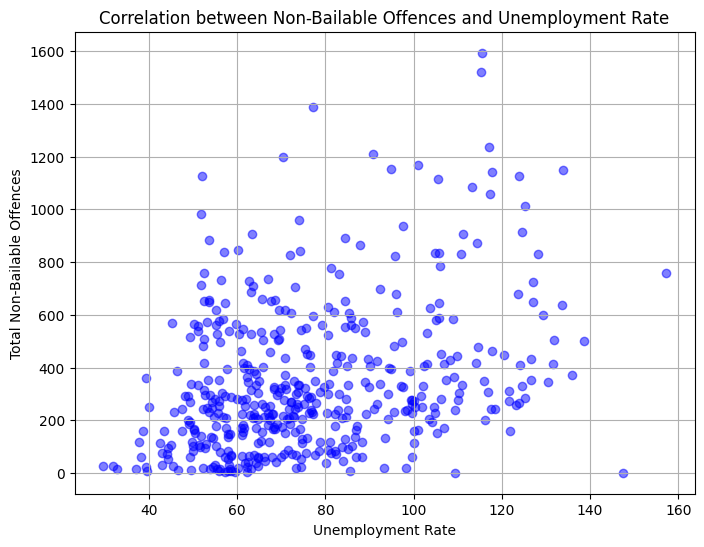

In [28]:
# Drop duplicates based on the unemployment_rate column only
df_unique_unemployment_rate = df.drop_duplicates(subset=['unemployment_rate'])

correlation = df['Total Non-Bailable Offences'].corr(df_unique_unemployment_rate['unemployment_rate'])
print("Correlation between Non-Bailable Offences and Unemployment Rate:", correlation)

plt.figure(figsize=(8, 6))
plt.scatter(df_unique_unemployment_rate['unemployment_rate'], df_unique_unemployment_rate['Total Non-Bailable Offences'], color='blue', alpha=0.5)
plt.title('Correlation between Non-Bailable Offences and Unemployment Rate')
plt.xlabel('Unemployment Rate')
plt.ylabel('Total Non-Bailable Offences')
plt.grid(True)
plt.show()

<H3><LI>Correlation between Non-Bailable offences and Literacy Rate</LI></H3>

Correlation between Literacy Rate and Non-Bailable Crimes: -0.03434625292633456


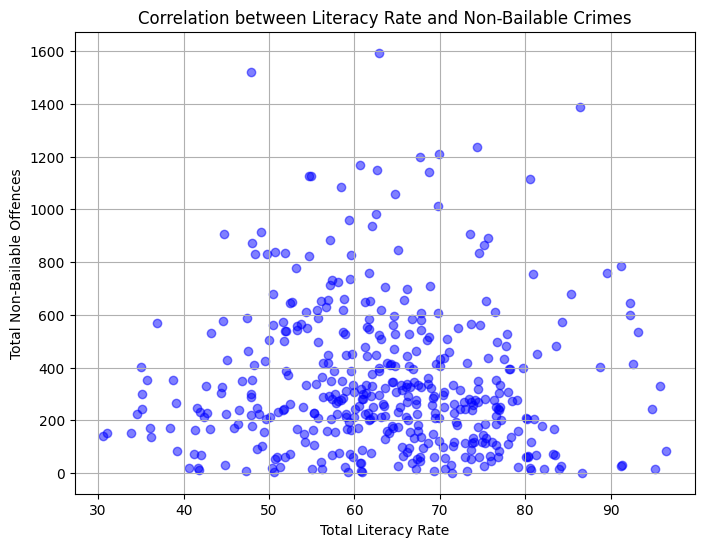

In [29]:
# Drop duplicate values from the Total Literacy Rate column
df_unique_literacy = df.drop_duplicates(subset=['Total Literacy Rate'])

correlation = df_unique_literacy['Total Non-Bailable Offences'].corr(df_unique_literacy['Total Literacy Rate'])

print("Correlation between Literacy Rate and Non-Bailable Crimes:", correlation)

plt.figure(figsize=(8, 6))
plt.scatter(df_unique_literacy['Total Literacy Rate'], df_unique_literacy['Total Non-Bailable Offences'], color='blue', alpha=0.5)
plt.title('Correlation between Literacy Rate and Non-Bailable Crimes')
plt.xlabel('Total Literacy Rate')
plt.ylabel('Total Non-Bailable Offences')
plt.grid(True)
plt.show()


In [30]:
df.columns

Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Total Population',
       'Male Population', 'Female Population', 'rural_population',
       'Total Literacy Rate', 'Male Literacy Rate', 'Female Literacy Rate',
       'First Dominant Religion', 'Second Dominant Religion',
       'unemployment_rate', 'urban_population', 'Total Cognizable Offences',
       'Total Non-Bailable Offences'],
      dtype='object')

<H3>Histogram of Total Cognizable Offenses vs Non-Bailable Offences</H3>

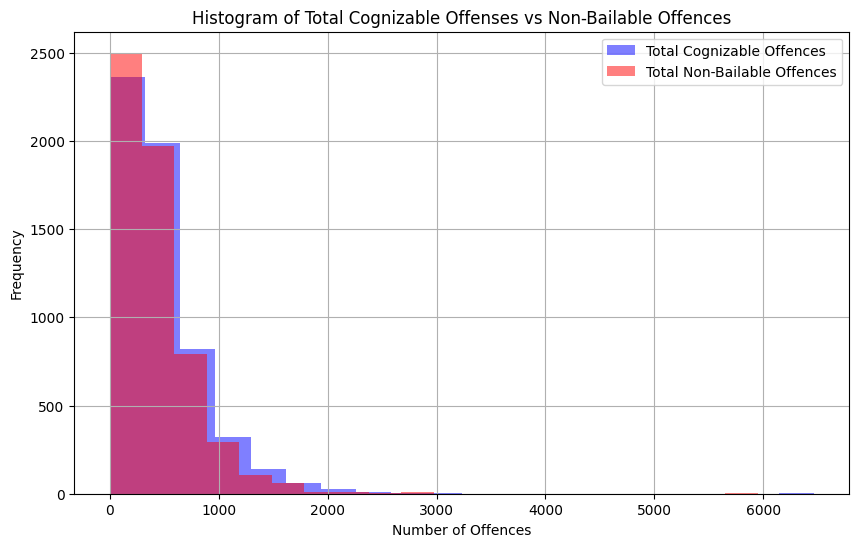

In [31]:

df_unique = df.drop_duplicates(subset=['Total Cognizable Offences', 'Total Non-Bailable Offences'])
df_unique_population = df.drop_duplicates(subset=['urban_population', 'rural_population'])

# Plot histogram of total cognizable offenses versus non-bailable offenses
plt.figure(figsize=(10, 6))
plt.hist(df_unique['Total Cognizable Offences'], bins=20, alpha=0.5, label='Total Cognizable Offences', color='blue')
plt.hist(df_unique['Total Non-Bailable Offences'], bins=20, alpha=0.5, label='Total Non-Bailable Offences', color='red')
plt.xlabel('Number of Offences')
plt.ylabel('Frequency')
plt.title('Histogram of Total Cognizable Offenses vs Non-Bailable Offences')
plt.legend()
plt.grid(True)
plt.show()



<h3>Frequency of Dominant Religions Associated with Cognizable Offenses</h3>


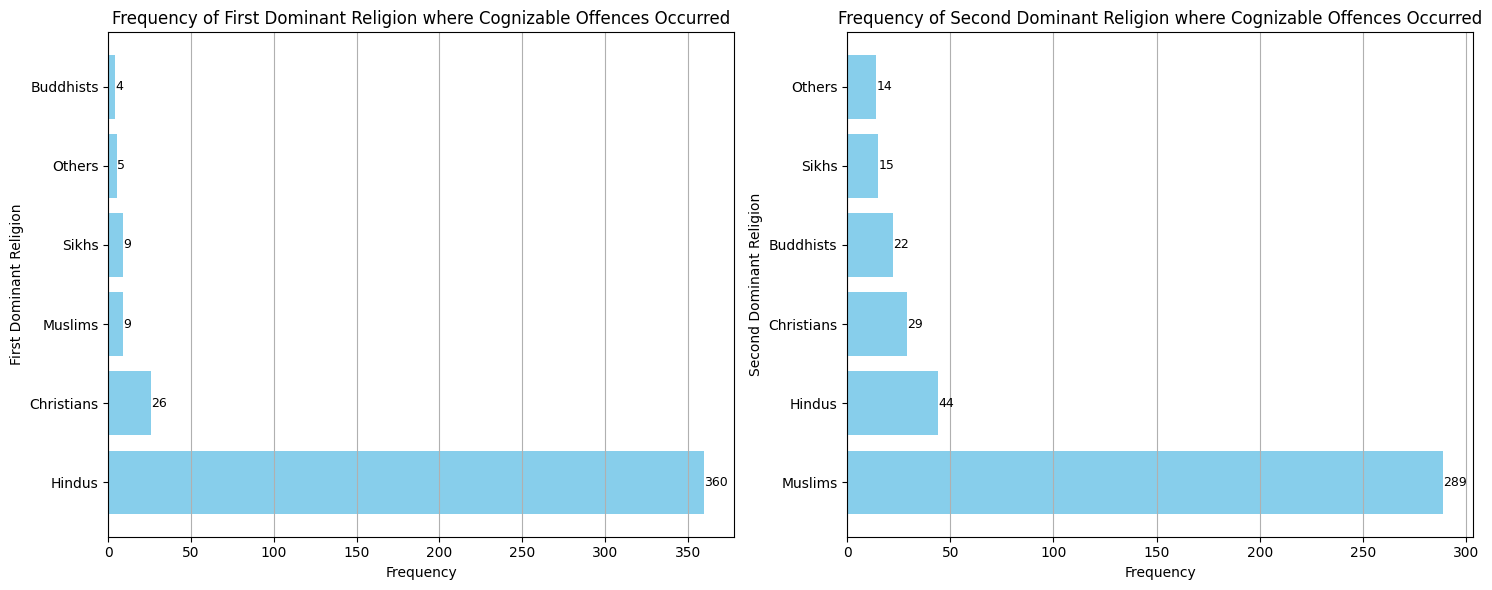

In [34]:
df_unique_districts = df[['District', 'First Dominant Religion', 'Second Dominant Religion']].drop_duplicates()
religion_counts = df_unique_districts['First Dominant Religion'].value_counts()
religion_counts_second = df_unique_districts['Second Dominant Religion'].value_counts()

# Plot the frequency of each dominant religion for the second dominant religion
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
bars1 = plt.barh(religion_counts.index, religion_counts.values, color='skyblue')

plt.xlabel('Frequency')
plt.ylabel('First Dominant Religion')
plt.title('Frequency of First Dominant Religion where Cognizable Offences Occurred')
plt.grid(axis='x')

# Add annotations for each bar in the first subplot
for bar in bars1:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}', 
             va='center', ha='left', fontsize=9)

# Plot the frequency of each dominant religion for the second dominant religion
plt.subplot(1, 2, 2)
bars2 = plt.barh(religion_counts_second.index, religion_counts_second.values, color='skyblue')

plt.xlabel('Frequency')
plt.ylabel('Second Dominant Religion')
plt.title('Frequency of Second Dominant Religion where Cognizable Offences Occurred')
plt.grid(axis='x')

# Add annotations for each bar in the second subplot
for bar in bars2:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.0f}', 
             va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()
